<a href="https://colab.research.google.com/github/arjun-695/Network_Intrussion_Detector/blob/main/ids_cicids2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN-BiLSTM-MHA Intrusion Detection — CIC-IDS-2017
**Architecture:** CNN → BiLSTM → Multi-Head Attention → Classifier
**Dataset:** CIC-IDS-2017 (Canadian Institute for Cybersecurity)
**Approach:** Two-Stage — Random Forest (binary) → Attack-only ensemble (NN + XGBoost)


In [ ]:
!pip install -q imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
from tqdm import tqdm
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, gc, warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Load CIC-IDS-2017 Dataset

In [ ]:
import glob, os

path = "/kaggle/input/datasets/dhoogla/cicids2017"

# List all parquet files
parquet_files = glob.glob(os.path.join(path, "**/*.parquet"), recursive=True)
print(f"Found {len(parquet_files)} parquet files:")
for f in parquet_files:
    print(f"  {os.path.basename(f)}")



Found 8 parquet files:
  Benign-Monday-no-metadata.parquet
  Bruteforce-Tuesday-no-metadata.parquet
  Portscan-Friday-no-metadata.parquet
  WebAttacks-Thursday-no-metadata.parquet
  DoS-Wednesday-no-metadata.parquet
  DDoS-Friday-no-metadata.parquet
  Infiltration-Thursday-no-metadata.parquet
  Botnet-Friday-no-metadata.parquet


In [ ]:
dfs = []
for f in parquet_files:
    print(f"Loading {os.path.basename(f)}...", end=" ")
    chunk = pd.read_parquet(f)
    print(f"→ {len(chunk):,} rows, {chunk.shape[1]} cols")
    dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df):,} rows × {df.shape[1]} columns")

# Clean column names
df.columns = df.columns.str.strip()
print(f"\nColumns: {list(df.columns[:10])} ... {list(df.columns[-5:])}")




Loading Benign-Monday-no-metadata.parquet... → 458,831 rows, 78 cols
Loading Bruteforce-Tuesday-no-metadata.parquet... → 389,714 rows, 78 cols
Loading Portscan-Friday-no-metadata.parquet... → 119,522 rows, 78 cols
Loading WebAttacks-Thursday-no-metadata.parquet... → 155,820 rows, 78 cols
Loading DoS-Wednesday-no-metadata.parquet... → 584,991 rows, 78 cols
Loading DDoS-Friday-no-metadata.parquet... → 221,264 rows, 78 cols
Loading Infiltration-Thursday-no-metadata.parquet... → 207,630 rows, 78 cols
Loading Botnet-Friday-no-metadata.parquet... → 176,038 rows, 78 cols

Total: 2,313,810 rows × 78 columns

Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std'] ... ['Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label']


In [ ]:
# Check label column
label_col = 'Label'  # CIC-IDS-2017 standard
if label_col not in df.columns:
    # Try alternate names
    for col in df.columns:
        if 'label' in col.lower():
            label_col = col
            break

print(f"Label column: '{label_col}'")
print(f"\nLabel distribution:")
print(df[label_col].value_counts())
print(f"\nUnique labels: {df[label_col].nunique()}")


Label column: 'Label'

Label distribution:
Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Unique labels: 15


## 2. Label Mapping — 7 Attack Categories

In [ ]:
# Map specific attacks to categories
LABEL_MAP = {
    'BENIGN': 'Normal',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'Heartbleed': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    'Web Attack \u2013 Brute Force': 'WebAttack',
    'Web Attack \u2013 XSS': 'WebAttack',
    'Web Attack \u2013 Sql Injection': 'WebAttack',
    'Web Attack - Brute Force': 'WebAttack',
    'Web Attack - XSS': 'WebAttack',
    'Web Attack - Sql Injection': 'WebAttack',
    'Bot': 'Bot',
    'Infiltration': 'Infiltration',
}

# Apply mapping (unknown labels → 'Other')
df['category'] = df[label_col].map(LABEL_MAP).fillna('Other')

# Drop 'Other' and 'Infiltration' if too few samples
min_samples = 50
cat_counts = df['category'].value_counts()
valid_cats = cat_counts[cat_counts >= min_samples].index.tolist()
df = df[df['category'].isin(valid_cats)].reset_index(drop=True)

# Encode to integers
CLASS_NAMES = sorted(df['category'].unique())
label_enc = {name: i for i, name in enumerate(CLASS_NAMES)}
df['target'] = df['category'].map(label_enc)

print("CLASS MAPPING:")
for name, idx in sorted(label_enc.items(), key=lambda x: x[1]):
    count = (df['target'] == idx).sum()
    print(f"  {idx}: {name:15s} → {count:>10,} samples")
print(f"\nTotal classes: {len(CLASS_NAMES)}")
print(f"Total samples: {len(df):,}")


CLASS MAPPING:
  0: Bot             →      1,437 samples
  1: BruteForce      →      9,150 samples
  2: DDoS            →    128,014 samples
  3: DoS             →    193,756 samples
  4: Other           →  1,979,461 samples
  5: PortScan        →      1,956 samples

Total classes: 6
Total samples: 2,313,774


## 3. Feature Engineering & Cleaning

In [ ]:
# Drop non-feature columns
DROP_COLS = [label_col, 'category', 'target']
# Also drop IP/port/timestamp if present
for col in df.columns:
    cl = col.lower()
    if any(x in cl for x in ['source ip', 'destination ip', 'timestamp',
                               'flow id', 'src ip', 'dst ip', 'source port',
                               'destination port']):
        DROP_COLS.append(col)

FEAT_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f"Feature columns: {len(FEAT_COLS)}")

# Convert to numeric, coerce errors
X_df = df[FEAT_COLS].apply(pd.to_numeric, errors='coerce')

# Replace infinity with NaN, then fill NaN with 0
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_counts = X_df.isna().sum().sum()
print(f"NaN/Inf values found: {nan_counts:,} → filling with 0")
X_df.fillna(0, inplace=True)

# Remove constant columns (zero variance)
variance = X_df.var()
const_cols = variance[variance == 0].index.tolist()
if const_cols:
    print(f"Dropping {len(const_cols)} constant columns: {const_cols[:5]}...")
    X_df.drop(columns=const_cols, inplace=True)
    FEAT_COLS = [c for c in FEAT_COLS if c not in const_cols]

print(f"Final feature count: {len(FEAT_COLS)}")
print(f"Data shape: {X_df.shape}")


Feature columns: 77
NaN/Inf values found: 0 → filling with 0
Dropping 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate']...
Final feature count: 69
Data shape: (2313774, 69)


In [ ]:
# --- Subsample if dataset is too large (>500K) ---
MAX_SAMPLES = 500_000

if len(df) > MAX_SAMPLES:
    print(f"Dataset too large ({len(df):,}). Stratified sampling to {MAX_SAMPLES:,}...")
    # Stratified sample
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, train_size=MAX_SAMPLES, random_state=42)
    idx, _ = next(sss.split(X_df, df['target']))
    X_df = X_df.iloc[idx].reset_index(drop=True)
    y_all = df['target'].iloc[idx].values.astype(np.int64)
    print(f"Sampled distribution: {Counter(y_all)}")
else:
    y_all = df['target'].values.astype(np.int64)

# Train/test split (80/20, stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_df.values.astype(np.float32), y_all,
    test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Clip extreme values after scaling
X_train = np.clip(X_train, -10, 10).astype(np.float32)
X_test  = np.clip(X_test,  -10, 10).astype(np.float32)

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(CLASS_NAMES)
print(f"Features: {N_FEATURES} | Classes: {N_CLASSES}")
print(f"\nTrain class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_train == i).sum()
    print(f"  {name:15s}: {count:>8,}")

del X_df, df, dfs
gc.collect()


Dataset too large (2,313,774). Stratified sampling to 500,000...
Sampled distribution: Counter({np.int64(4): 427756, np.int64(3): 41870, np.int64(2): 27663, np.int64(1): 1977, np.int64(5): 423, np.int64(0): 311})
Train: 400,000 | Test: 100,000
Features: 69 | Classes: 6

Train class distribution:
  Bot            :      249
  BruteForce     :    1,582
  DDoS           :   22,130
  DoS            :   33,496
  Other          :  342,205
  PortScan       :      338


566

In [ ]:
# SMOTE for minority classes
print(f"Before SMOTE: {Counter(y_train)}")

majority_count = max(Counter(y_train).values())
min_target = majority_count // 10

sampling_strategy = {}
for cls, count in Counter(y_train).items():
    if count < min_target:
        sampling_strategy[cls] = min_target

if sampling_strategy:
    print(f"SMOTE strategy: {sampling_strategy}")
    sm = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=sampling_strategy)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    print(f"After SMOTE: {Counter(y_train)}")
else:
    print("No SMOTE needed — classes are balanced enough")


Before SMOTE: Counter({np.int64(4): 342205, np.int64(3): 33496, np.int64(2): 22130, np.int64(1): 1582, np.int64(5): 338, np.int64(0): 249})
SMOTE strategy: {np.int64(3): 34220, np.int64(2): 34220, np.int64(1): 34220, np.int64(5): 34220, np.int64(0): 34220}
After SMOTE: Counter({np.int64(4): 342205, np.int64(3): 34220, np.int64(2): 34220, np.int64(1): 34220, np.int64(5): 34220, np.int64(0): 34220})


## 4. Sequence Creation for LSTM

In [ ]:
SEQ_LEN = 30

def make_sequences(X, y, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

X_train_seq, y_train_seq = make_sequences(X_train, y_train)
X_test_seq, y_test_seq   = make_sequences(X_test, y_test)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences:  {X_test_seq.shape}")
print(f"\nSequence class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_train_seq == i).sum()
    print(f"  {name:15s}: {count:>8,}")

class IDSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = IDSDataset(X_train_seq, y_train_seq)
test_ds  = IDSDataset(X_test_seq, y_test_seq)

BATCH = 512
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train sequences: (513276, 30, 69)
Test sequences:  (99971, 30, 69)

Sequence class distribution:
  Bot            :   34,220
  BruteForce     :   34,220
  DDoS           :   34,219
  DoS            :   34,216
  Other          :  342,181
  PortScan       :   34,220

Train batches: 1003
Test batches:  196


## 5. CNN-BiLSTM-MHA Architecture

In [ ]:
class CNN_BiLSTM_MHA_IDS(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, n_classes=N_CLASSES, dropout=0.3):
        super().__init__()

        # Input projection + normalization
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # 1D CNN for local pattern extraction
        self.cnn = nn.Sequential(
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
        )

        # Stacked Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=hidden,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # Multi-Head Self Attention (4 heads)
        self.mha = nn.MultiheadAttention(
            hidden * 2, num_heads=4,
            dropout=0.1, batch_first=True
        )

        self.attn_norm = nn.LayerNorm(hidden * 2)
        self.attn = nn.Linear(hidden * 2, 1)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        attn_out, _ = self.mha(out, out, out)
        out = self.attn_norm(out + attn_out)
        attn_w = torch.softmax(self.attn(out), dim=1)
        context = (out * attn_w).sum(1)
        return self.classifier(context)

model = CNN_BiLSTM_MHA_IDS(n_features=N_FEATURES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)


Parameters: 1,131,143
CNN_BiLSTM_MHA_IDS(
  (input_proj): Sequential(
    (0): Linear(in_features=69, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (cnn): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (attn_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Seque

## 6. Training — Focal Loss + OneCycleLR

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# Class weights
class_counts = np.bincount(y_train_seq, minlength=N_CLASSES)
class_counts = np.maximum(class_counts, 1)
class_weights = len(y_train_seq) / (N_CLASSES * class_counts)
class_weights = np.clip(class_weights, 0.5, 5.0)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Class weights: {class_weights.round(3)}")

criterion = FocalLoss(alpha=weights_tensor, gamma=2.0)
EPOCHS = 30
LR = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS, pct_start=0.1
)

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
best_val_acc = 0.0
history = {'train_acc': [], 'val_acc': [], 'loss': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f'Ep {epoch:02d}', leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_acc = correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb).argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_acc = val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    avg_loss = total_loss / len(train_loader)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['loss'].append(avg_loss)
    history['lr'].append(current_lr)

    gap = train_acc - val_acc
    flag = " ⚠ OVERFIT" if gap > 0.10 else ""

    print(f'Epoch {epoch:02d} | Loss: {avg_loss:.4f} | '
          f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | '
          f'Gap: {gap:.4f}{flag} | LR: {current_lr:.2e}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/kaggle/working/checkpoints/best_cicids.pth')
        print(f'  ✓ Saved best (Val: {val_acc:.4f})')

print(f'\n{"="*60}')
print(f'Best Validation Accuracy: {best_val_acc:.4f}')
print(f'{"="*60}')


Class weights: [2.5 2.5 2.5 2.5 0.5 2.5]


Epoch 01 | Loss: 0.5258 | Train: 0.6171 | Val: 0.8803 | Gap: -0.2632 | LR: 8.40e-05
  ✓ Saved best (Val: 0.8803)


Epoch 02 | Loss: 0.0502 | Train: 0.9317 | Val: 0.9214 | Gap: 0.0104 | LR: 2.28e-04
  ✓ Saved best (Val: 0.9214)


Epoch 03 | Loss: 0.0271 | Train: 0.9436 | Val: 0.9359 | Gap: 0.0078 | LR: 3.00e-04
  ✓ Saved best (Val: 0.9359)


Epoch 04 | Loss: 0.0200 | Train: 0.9511 | Val: 0.9565 | Gap: -0.0053 | LR: 2.99e-04
  ✓ Saved best (Val: 0.9565)


...

Epoch 26 | Loss: 0.0060 | Train: 0.9811 | Val: 0.9779 | Gap: 0.0032 | LR: 1.59e-05


Epoch 27 | Loss: 0.0059 | Train: 0.9814 | Val: 0.9792 | Gap: 0.0022 | LR: 9.04e-06
  ✓ Saved best (Val: 0.9792)


Epoch 28 | Loss: 0.0056 | Train: 0.9819 | Val: 0.9787 | Gap: 0.0032 | LR: 4.04e-06


Epoch 29 | Loss: 0.0057 | Train: 0.9822 | Val: 0.9786 | Gap: 0.0036 | LR: 1.01e-06


Epoch 30 | Loss: 0.0056 | Train: 0.9823 | Val: 0.9791 | Gap: 0.0032 | LR: 1.20e-09

Best Validation Accuracy: 0.9792


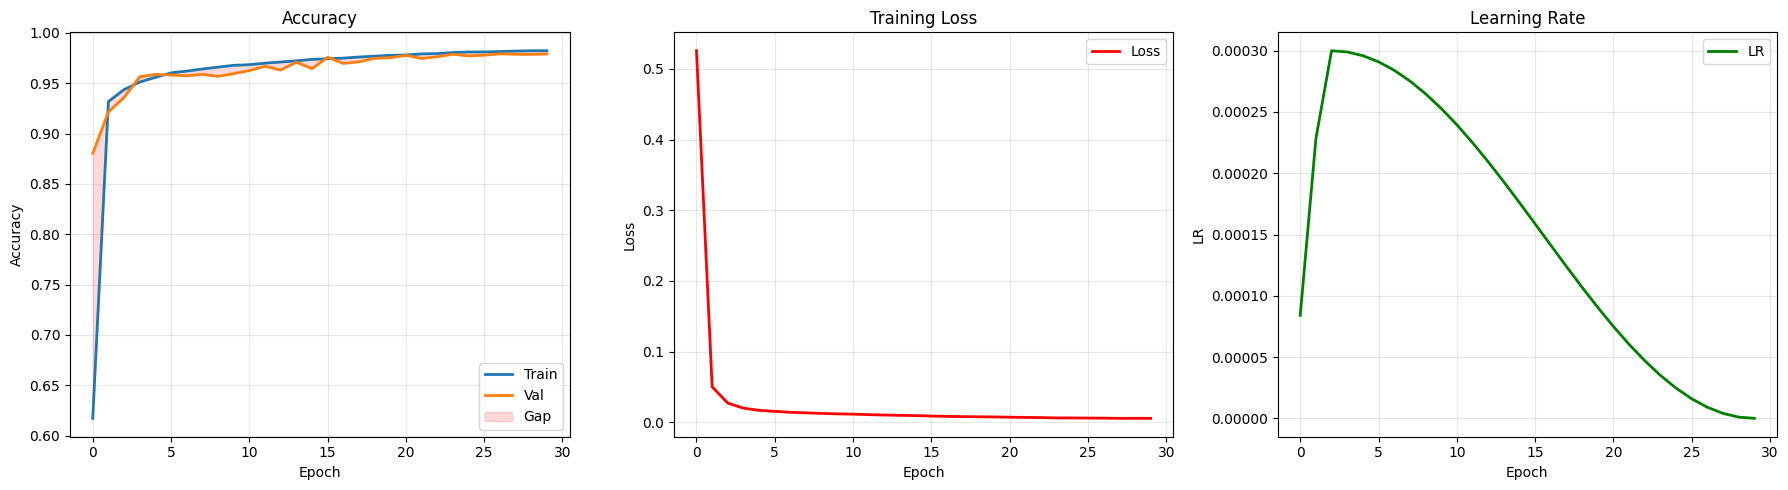

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_acc'], label='Train', linewidth=2)
axes[0].plot(history['val_acc'],   label='Val',   linewidth=2)
axes[0].fill_between(range(EPOCHS), history['train_acc'], history['val_acc'],
                     alpha=0.15, color='red', label='Gap')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')

axes[1].plot(history['loss'], color='red', linewidth=2, label='Loss')
axes[1].set_title('Training Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

axes[2].plot(history['lr'], color='green', linewidth=2, label='LR')
axes[2].set_title('Learning Rate'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()


## 7. Evaluation — Classification Report + Confusion Matrix

CNN-BiLSTM-MHA Accuracy: 0.9792

Classification Report:
              precision    recall  f1-score   support

         Bot     0.2126    0.7097    0.3271        62
  BruteForce     0.9642    0.9544    0.9593       395
        DDoS     0.9919    0.9986    0.9952      5532
         DoS     0.8292    0.9967    0.9053      8370
       Other     0.9992    0.9766    0.9878     85527
    PortScan     0.5170    0.8941    0.6552        85

    accuracy                         0.9792     99971
   macro avg     0.7523    0.9217    0.8050     99971
weighted avg     0.9835    0.9792    0.9805     99971

PER-CLASS ACCURACY:
  Bot            : 0.7097 (62 samples)
  BruteForce     : 0.9544 (395 samples)
  DDoS           : 0.9986 (5,532 samples)
  DoS            : 0.9967 (8,370 samples)
  Other          : 0.9766 (85,527 samples)
  PortScan       : 0.8941 (85 samples)


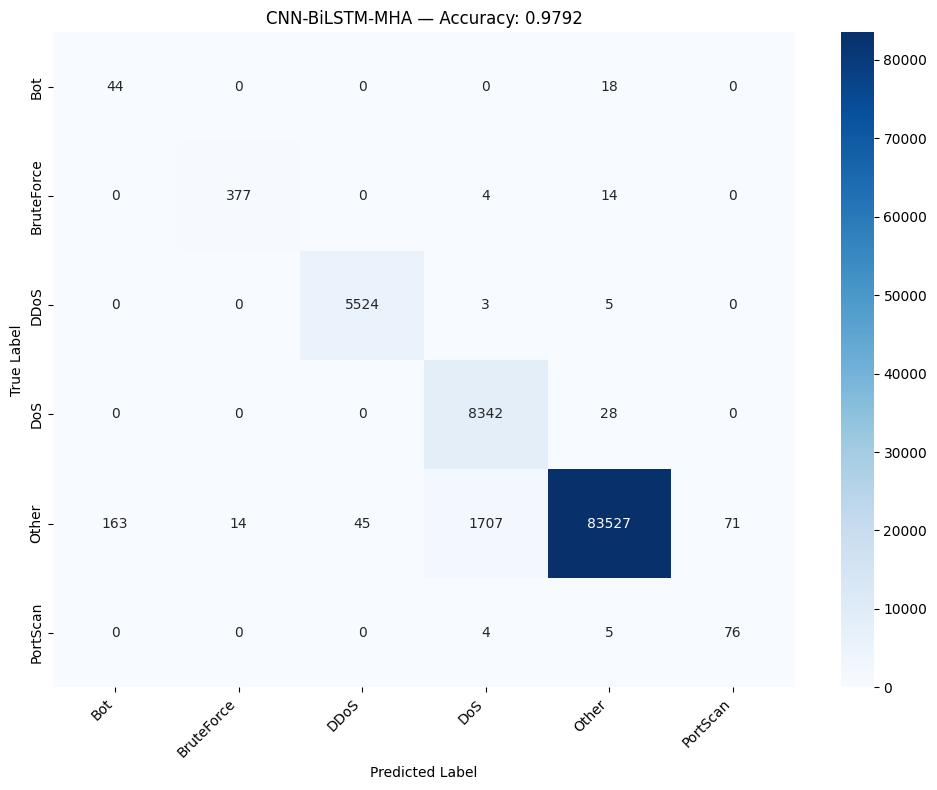

In [ ]:
# Load best model
model.load_state_dict(torch.load('/kaggle/working/checkpoints/best_cicids.pth'))
model.eval()

all_preds, all_labels = [], []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_probs.append(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
nn_probs   = np.vstack(all_probs)

nn_acc = accuracy_score(all_labels, all_preds)
print(f"CNN-BiLSTM-MHA Accuracy: {nn_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds,
                          target_names=CLASS_NAMES, digits=4))

print("PER-CLASS ACCURACY:")
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    if mask.sum() > 0:
        acc = (all_preds[mask] == i).mean()
        print(f"  {name:15s}: {acc:.4f} ({mask.sum():,} samples)")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'CNN-BiLSTM-MHA — Accuracy: {nn_acc:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_nn.png', dpi=150)
plt.show()


## 8. XGBoost Ensemble

[0]	validation_0-mlogloss:0.59618
[50]	validation_0-mlogloss:0.01196
[100]	validation_0-mlogloss:0.00510
[150]	validation_0-mlogloss:0.00402
[200]	validation_0-mlogloss:0.00375
[250]	validation_0-mlogloss:0.00365
[300]	validation_0-mlogloss:0.00361
[350]	validation_0-mlogloss:0.00360
[400]	validation_0-mlogloss:0.00360
[406]	validation_0-mlogloss:0.00360

XGBoost Accuracy: 0.9988

NN alone:              0.9792
XGBoost alone:         0.9988
ENSEMBLE (w=0.45):     0.9990

ENSEMBLE Classification Report:
              precision    recall  f1-score   support

         Bot     0.5532    0.8387    0.6667        62
  BruteForce     0.9924    0.9949    0.9937       395
        DDoS     1.0000    0.9998    0.9999      5532
         DoS     0.9968    0.9986    0.9977      8370
       Other     0.9997    0.9991    0.9994     85527
    PortScan     0.9419    0.9529    0.9474        85

    accuracy                         0.9990     99971
   macro avg     0.9140    0.9640    0.9341     99971
weigh

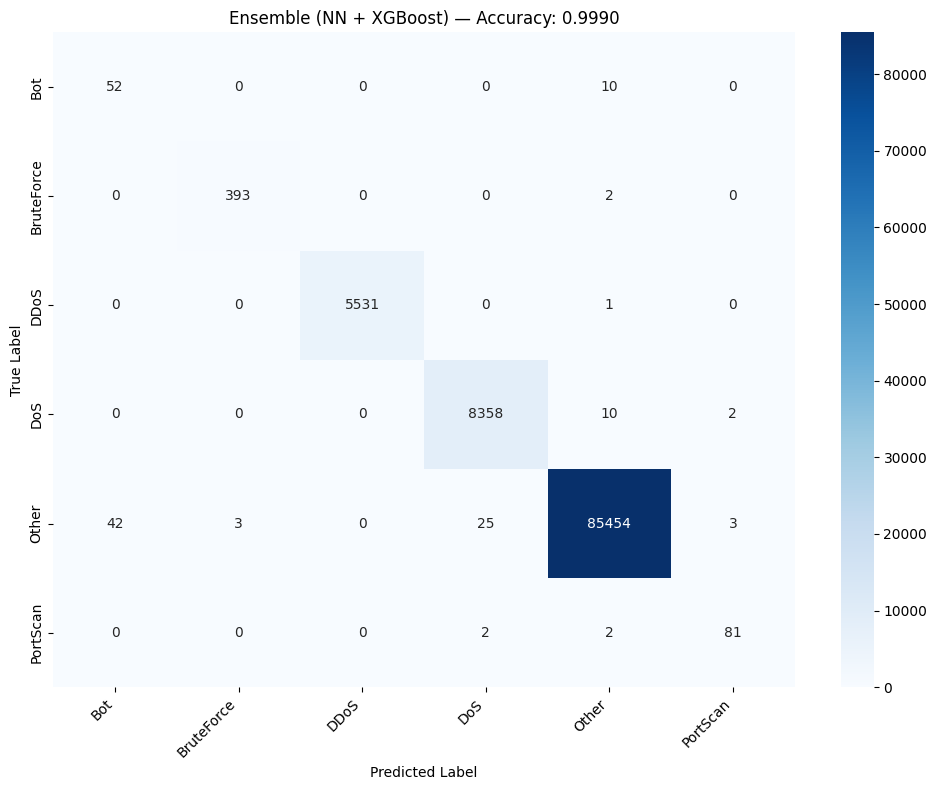

In [ ]:
# Train XGBoost on flat features
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2.0,
    n_jobs=-1,
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    early_stopping_rounds=50
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=50)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"\nXGBoost Accuracy: {xgb_acc:.4f}")

# Align XGBoost probs with NN sequences
xgb_probs_full = xgb_model.predict_proba(X_test)
xgb_probs = xgb_probs_full[SEQ_LEN-1:]

# Ensemble sweep
best_ens_acc, best_w = 0, 0
for w in np.arange(0.1, 0.95, 0.05):
    ens = w * nn_probs + (1 - w) * xgb_probs
    preds = ens.argmax(axis=1)
    acc = accuracy_score(all_labels, preds)
    if acc > best_ens_acc:
        best_ens_acc = acc
        best_w = w

print(f"\n{'='*60}")
print(f"NN alone:              {nn_acc:.4f}")
print(f"XGBoost alone:         {xgb_acc:.4f}")
print(f"ENSEMBLE (w={best_w:.2f}):     {best_ens_acc:.4f}")
print(f"{'='*60}")

# Final ensemble
ensemble_probs = best_w * nn_probs + (1 - best_w) * xgb_probs
ensemble_preds = ensemble_probs.argmax(axis=1)

print(f"\nENSEMBLE Classification Report:")
print(classification_report(all_labels, ensemble_preds,
                          target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, ensemble_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Ensemble (NN + XGBoost) — Accuracy: {best_ens_acc:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_ensemble.png', dpi=150)
plt.show()


## 9. Two-Stage: RF Binary → Attack-Only Ensemble

In [ ]:
# ══ STAGE 1: Random Forest — Normal vs Attack ══
y_train_binary = (y_train > 0).astype(np.int64) if CLASS_NAMES[0] == 'Normal' else None

# Auto-detect normal class
if y_train_binary is None:
    normal_idx = CLASS_NAMES.index('Normal') if 'Normal' in CLASS_NAMES else 0
    y_train_binary = (y_train != normal_idx).astype(np.int64)
    y_test_binary  = (y_test  != normal_idx).astype(np.int64)
else:
    y_test_binary = (y_test > 0).astype(np.int64)

print("STAGE 1: Training RF (Normal vs Attack)")
rf_binary = RandomForestClassifier(
    n_estimators=500, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_binary.fit(X_train, y_train_binary)

rf_preds = rf_binary.predict(X_test)
print(f"RF Binary Accuracy: {accuracy_score(y_test_binary, rf_preds):.4f}")
print(classification_report(y_test_binary, rf_preds,
                          target_names=['Normal','Attack'], digits=4))

# ══ STAGE 2: Attack-only models ══
normal_idx = CLASS_NAMES.index('Normal') if 'Normal' in CLASS_NAMES else 0
att_mask = y_train != normal_idx
X_train_att = X_train[att_mask]
y_train_att = y_train[att_mask]

# Remap attack labels to 0-indexed
unique_att = sorted(np.unique(y_train_att))
att_remap = {old: new for new, old in enumerate(unique_att)}
att_remap_inv = {new: old for old, new in att_remap.items()}
y_train_att_mapped = np.array([att_remap[y] for y in y_train_att])

ATT_NAMES = [CLASS_NAMES[att_remap_inv[i]] for i in range(len(unique_att))]
print(f"\nAttack classes: {ATT_NAMES}")
print(f"Attack train samples: {len(y_train_att_mapped):,}")

# Attack XGBoost
att_mask_test = y_test != normal_idx
X_test_att = X_test[att_mask_test]
y_test_att = y_test[att_mask_test]
y_test_att_mapped = np.array([att_remap.get(y, 0) for y in y_test_att])

xgb_att = xgb.XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', device='cuda',
    eval_metric='mlogloss', early_stopping_rounds=50,
    n_jobs=-1, random_state=42
)
xgb_att.fit(X_train_att, y_train_att_mapped,
            eval_set=[(X_test_att, y_test_att_mapped)], verbose=50)

print(f"\nAttack XGBoost Accuracy: {accuracy_score(y_test_att_mapped, xgb_att.predict(X_test_att)):.4f}")


STAGE 1: Training RF (Normal vs Attack)
RF Binary Accuracy: 0.9968
              precision    recall  f1-score   support

      Normal     0.1511    0.8871    0.2582        62
      Attack     0.9999    0.9969    0.9984     99938

    accuracy                         0.9968    100000
   macro avg     0.5755    0.9420    0.6283    100000
weighted avg     0.9994    0.9968    0.9980    100000


Attack classes: ['BruteForce', 'DDoS', 'DoS', 'Other', 'PortScan']
Attack train samples: 479,085
[0]	validation_0-mlogloss:0.53496
[50]	validation_0-mlogloss:0.00704
[100]	validation_0-mlogloss:0.00202
[150]	validation_0-mlogloss:0.00171
[200]	validation_0-mlogloss:0.00172
[204]	validation_0-mlogloss:0.00172

Attack XGBoost Accuracy: 0.9995


THRESHOLD SWEEP:
  t=0.50 | Acc: 0.9963 | Att Recall: 0.9969
  t=0.60 | Acc: 0.9973 | Att Recall: 0.9979
  t=0.70 | Acc: 0.9976 | Att Recall: 0.9982
  t=0.80 | Acc: 0.9979 | Att Recall: 0.9986
  t=0.85 | Acc: 0.9983 | Att Recall: 0.9989
  t=0.90 | Acc: 0.9987 | Att Recall: 0.9994
  t=0.93 | Acc: 0.9988 | Att Recall: 0.9995
  t=0.95 | Acc: 0.9990 | Att Recall: 0.9997

Using best threshold: 0.95

NN alone:         0.9792
XGBoost alone:    0.9988
Ensemble:         0.9990
TWO-STAGE:        0.9990

Final Classification Report:
              precision    recall  f1-score   support

         Bot     0.5806    0.5806    0.5806        62
  BruteForce     0.9949    0.9949    0.9949       395
        DDoS     1.0000    0.9996    0.9998      5533
         DoS     0.9967    0.9984    0.9976      8374
       Other     0.9995    0.9993    0.9994     85551
    PortScan     0.9412    0.9412    0.9412        85

    accuracy                         0.9990    100000
   macro avg     0.9188    0.9190    0

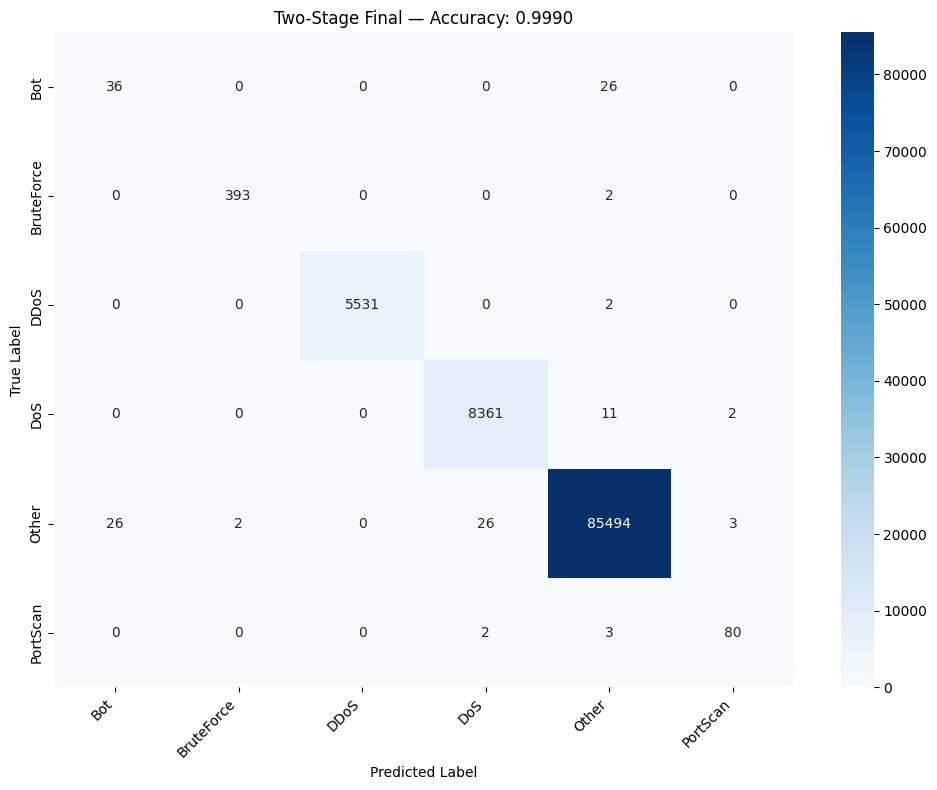

In [ ]:
# ══ COMBINED INFERENCE WITH THRESHOLD TUNING ══
rf_probs = rf_binary.predict_proba(X_test)
xgb_att_probs = xgb_att.predict_proba(X_test)

# Threshold sweep
print("THRESHOLD SWEEP:")
best_t, best_t_acc = 0.5, 0
for t in [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.93, 0.95]:
    bp = 1 - (rf_probs[:, 0] >= t).astype(int)
    fp = np.full(len(X_test), normal_idx, dtype=np.int64)
    att_idx = np.where(bp == 1)[0]
    for idx in att_idx:
        pred_mapped = xgb_att_probs[idx].argmax()
        fp[idx] = att_remap_inv[pred_mapped]
    acc = accuracy_score(y_test, fp)
    att_recall = (bp[y_test_binary==1]==1).mean()
    print(f"  t={t:.2f} | Acc: {acc:.4f} | Att Recall: {att_recall:.4f}")
    if acc > best_t_acc:
        best_t_acc = acc
        best_t = t

# Final with best threshold
print(f"\nUsing best threshold: {best_t}")
NORMAL_THRESHOLD = best_t
binary_preds = 1 - (rf_probs[:, 0] >= NORMAL_THRESHOLD).astype(int)
attack_indices = np.where(binary_preds == 1)[0]

final_preds = np.full(len(X_test), normal_idx, dtype=np.int64)
for idx in attack_indices:
    pred_mapped = xgb_att_probs[idx].argmax()
    final_preds[idx] = att_remap_inv[pred_mapped]

final_acc = accuracy_score(y_test, final_preds)
print(f"\n{'='*60}")
print(f"NN alone:         {nn_acc:.4f}")
print(f"XGBoost alone:    {xgb_acc:.4f}")
print(f"Ensemble:         {best_ens_acc:.4f}")
print(f"TWO-STAGE:        {final_acc:.4f}")
print(f"{'='*60}")

print(f"\nFinal Classification Report:")
print(classification_report(y_test, final_preds,
                          target_names=CLASS_NAMES, digits=4))

print("PER-CLASS ACCURACY:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_test == i
    if mask.sum() > 0:
        acc = (final_preds[mask] == i).mean()
        print(f"  {name:15s}: {acc:.4f} ({mask.sum():,} samples)")

# Final confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Two-Stage Final — Accuracy: {final_acc:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_final.png', dpi=150)
plt.show()


In [ ]:
# Model comparison summary
print("="*60)
print("       MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<30s} {'Accuracy':>10s}")
print("-"*42)
print(f"{'CNN-BiLSTM-MHA (NN)':<30s} {nn_acc:>10.4f}")
print(f"{'XGBoost':<30s} {xgb_acc:>10.4f}")
print(f"{'Ensemble (NN + XGBoost)':<30s} {best_ens_acc:>10.4f}")
print(f"{'Two-Stage (RF → XGBoost)':<30s} {final_acc:>10.4f}")
print("="*60)


       MODEL COMPARISON SUMMARY
Model                            Accuracy
------------------------------------------
CNN-BiLSTM-MHA (NN)                0.9792
XGBoost                            0.9988
Ensemble (NN + XGBoost)            0.9990
Two-Stage (RF → XGBoost)           0.9990
